# Mundial26 — Phase 1: Data Loading & Exploratory Analysis

**Goal of this notebook:** load the historical international football data, clean it,
build the basic outcome label we'll predict, and explore the patterns that matter for
modeling (home advantage, goal distributions, how match counts changed over time).

> Run cells top to bottom. Make sure the four CSVs are in `data/raw/`.


## 1. Imports & settings

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Load the data
All four files from the Kaggle dataset live in `data/raw/`.

In [4]:
RAW = "../data/raw"

results = pd.read_csv(f"{RAW}/results.csv", parse_dates=["date"])
goalscorers = pd.read_csv(f"{RAW}/goalscorers.csv", parse_dates=["date"])
shootouts = pd.read_csv(f"{RAW}/shootouts.csv", parse_dates=["date"])
former_names = pd.read_csv(f"{RAW}/former_names.csv")

print("results:    ", results.shape)
print("goalscorers:", goalscorers.shape)
print("shootouts:  ", shootouts.shape)
results.head()

results:     (49477, 9)
goalscorers: (47663, 8)
shootouts:   (678, 5)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## 3. First look
Check dtypes, missing values, and the date range we're working with.

In [5]:
print(results.info())
print("\nMissing values:")
print(results.isna().sum())
print("\nDate range:", results['date'].min().date(), "->", results['date'].max().date())

<class 'pandas.DataFrame'>
RangeIndex: 49477 entries, 0 to 49476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49477 non-null  datetime64[us]
 1   home_team   49477 non-null  str           
 2   away_team   49477 non-null  str           
 3   home_score  49425 non-null  float64       
 4   away_score  49425 non-null  float64       
 5   tournament  49477 non-null  str           
 6   city        49477 non-null  str           
 7   country     49477 non-null  str           
 8   neutral     49477 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(2), str(5)
memory usage: 5.4 MB
None

Missing values:
date           0
home_team      0
away_team      0
home_score    52
away_score    52
tournament     0
city           0
country        0
neutral        0
dtype: int64

Date range: 1872-11-30 -> 2026-06-27


## 4. Build the outcome label

This is the target we'll eventually predict. From the home team's perspective:
- **home_win** if home_score > away_score
- **draw** if equal
- **away_win** if home_score < away_score

Note: the `neutral` column tells us whether the "home" team actually had home advantage —
we keep this because it's one of the strongest predictors in football.

In [6]:
def outcome(row):
    if row["home_score"] > row["away_score"]:
        return "home_win"
    elif row["home_score"] < row["away_score"]:
        return "away_win"
    return "draw"

results["result"] = results.apply(outcome, axis=1)
results["total_goals"] = results["home_score"] + results["away_score"]
results["goal_diff"] = results["home_score"] - results["away_score"]
results["year"] = results["date"].dt.year

results["result"].value_counts(normalize=True).round(3)

result
home_win    0.490
away_win    0.282
draw        0.228
Name: proportion, dtype: float64

## 5. Home advantage — does it actually exist?

We compare outcomes for non-neutral matches (real home advantage) vs neutral-site matches.
If home advantage is real, home win rate should drop noticeably at neutral venues.

In [7]:
home_adv = (
    results.groupby("neutral")["result"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
)
home_adv

,neutral,result,share
0,False,home_win,0.507344
1,False,away_win,0.263945
2,False,draw,0.228711
3,True,home_win,0.440287
4,True,away_win,0.332749
5,True,draw,0.226964


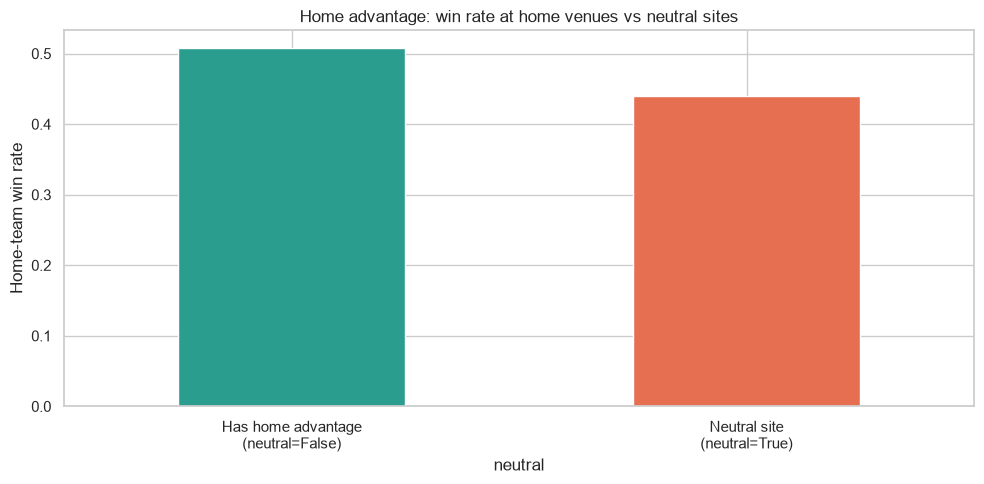

In [8]:
pivot = (
    results.assign(is_home_win=(results["result"] == "home_win"))
    .groupby("neutral")["is_home_win"].mean()
)
ax = pivot.plot(kind="bar", color=["#2a9d8f", "#e76f51"])
ax.set_xticklabels(["Has home advantage\n(neutral=False)", "Neutral site\n(neutral=True)"], rotation=0)
ax.set_ylabel("Home-team win rate")
ax.set_title("Home advantage: win rate at home venues vs neutral sites")
plt.tight_layout(); plt.show()

## 6. Goal distributions
How many goals do teams typically score? This shape matters a lot for the Poisson model in Phase 3.

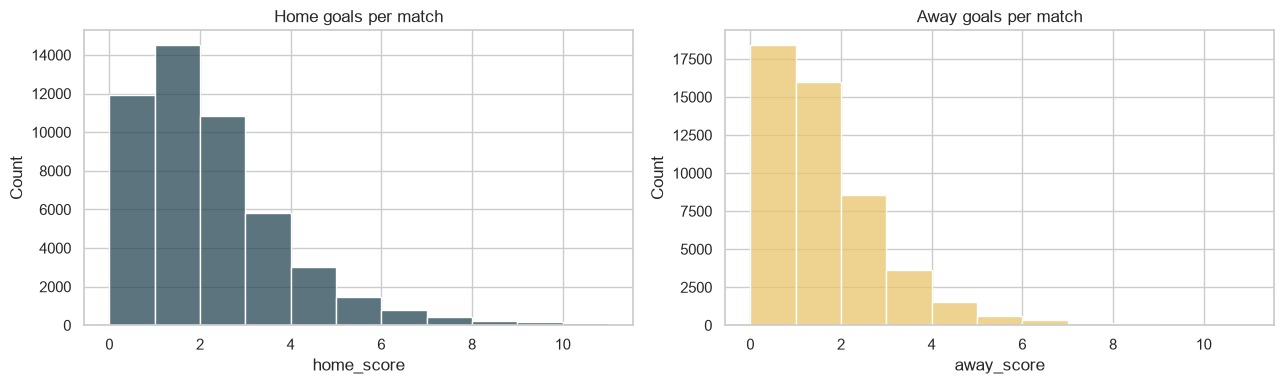

Avg home goals: 1.76
Avg away goals: 1.18


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(results["home_score"], bins=range(0, 12), ax=axes[0], color="#264653")
axes[0].set_title("Home goals per match")
sns.histplot(results["away_score"], bins=range(0, 12), ax=axes[1], color="#e9c46a")
axes[1].set_title("Away goals per match")
plt.tight_layout(); plt.show()

print("Avg home goals:", round(results["home_score"].mean(), 2))
print("Avg away goals:", round(results["away_score"].mean(), 2))

## 7. Matches over time
The sport globalized massively after ~1950. We may later restrict training to the modern era.

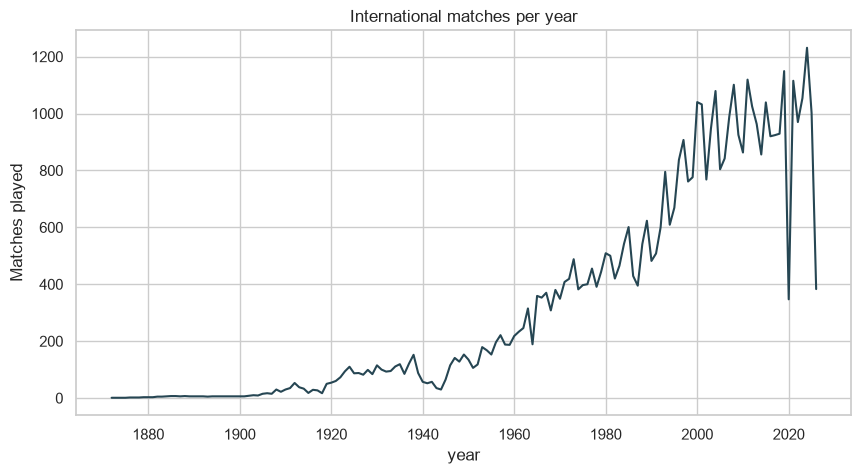

In [10]:
results.groupby("year").size().plot(color="#264653")
plt.ylabel("Matches played"); plt.title("International matches per year"); plt.show()

## 8. World Cup matches only
Filter to the tournament we actually care about, to sanity-check the data.

In [11]:
wc = results[results["tournament"] == "FIFA World Cup"]
print("World Cup matches in dataset:", len(wc))
print("Editions covered:", sorted(wc["year"].unique()))
wc.tail()

World Cup matches in dataset: 1036
Editions covered: [np.int32(1930), np.int32(1934), np.int32(1938), np.int32(1950), np.int32(1954), np.int32(1958), np.int32(1962), np.int32(1966), np.int32(1970), np.int32(1974), np.int32(1978), np.int32(1982), np.int32(1986), np.int32(1990), np.int32(1994), np.int32(1998), np.int32(2002), np.int32(2006), np.int32(2010), np.int32(2014), np.int32(2018), np.int32(2022), np.int32(2026)]


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,total_goals,goal_diff,year
49472,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True,draw,NaN,NaN,2026
49473,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,draw,NaN,NaN,2026
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True,draw,NaN,NaN,2026
49475,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True,draw,NaN,NaN,2026
49476,2026-06-27,Croatia,Ghana,NaN,NaN,FIFA World Cup,Philadelphia,United States,True,draw,NaN,NaN,2026


## 9. Save a processed copy

We write a cleaned version to `data/processed/` so later notebooks (modeling) load
this instead of re-doing the cleaning.

In [12]:
import os
os.makedirs("data/processed", exist_ok=True)
results.to_csv("data/processed/results_clean.csv", index=False)
print("Saved -> data/processed/results_clean.csv")

Saved -> data/processed/results_clean.csv


---
### What's next (Phase 2)
With the data clean and the outcome label built, the next notebook trains a baseline
classifier (logistic regression -> random forest -> XGBoost) to predict `result`,
using features like recent form, Elo gap, and the neutral-site flag. That baseline is
the number the Dixon-Coles model in Phase 3 has to beat.